In [75]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
from PIL import Image

def load_data():
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])
    
    dataset = ImageFolder(root='2750', transform=transform)
    
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    print(f'Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}')
    
    return train_loader, test_loader
    

In [76]:
import torch.nn as nn
from torchvision.models import resnet18

def build_model():
    model = resnet18(pretrained=True)
    model.fc = nn.Linear(512, 128) 
    return model

In [77]:
import torch.nn.functional as F

class CosineLayer(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):

        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)

        cosine = torch.mm(x, w.t())
        
        return cosine

In [78]:
def arcface_loss(cosine, labels, margin=0.5, scale=30):

    cosine = cosine.clamp(-1 + 1e-7, 1 - 1e-7)

    theta = torch.acos(cosine)

    one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()

    theta_m = theta + one_hot * margin

    cosine_m = torch.cos(theta_m)

    logits = cosine_m * scale

    loss = F.cross_entropy(logits, labels)

    return loss

In [84]:
def train(model, loader):

    best_loss = float('inf')
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
    model.to(device)

    cosine = CosineLayer(128, 10).to(device)

    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(cosine.parameters()),
        lr=1e-4
    )

    epochs = 10

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            features = model(images)

            cosine_output = cosine(features)

            loss = arcface_loss(cosine_output, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("Model saved")

In [90]:
def get_embeddings(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    embeddings = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)   # переносим данные на GPU
            labels = labels.to(device)   # тоже на GPU, чтобы можно было потом torch.cat
            emb = model(images)
            embeddings.append(emb)
            labels_list.append(labels)

    embeddings = torch.cat(embeddings)
    labels_list = torch.cat(labels_list)

    print(f'Embeddings shape: {embeddings.shape}, Labels shape: {labels_list.shape}')
    
    # переносим обратно на CPU для numpy
    return embeddings.cpu().numpy(), labels_list.cpu().numpy()

In [91]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_tsne(embeddings, labels):

    tsne = TSNE(n_components=2)

    X = tsne.fit_transform(embeddings)

    plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10')
    plt.show()

In [111]:
import random

def show_image_pairs(model, dataset, device="cuda", num_pairs=5, threshold=0.5):
    model.eval()
    model.to(device)
    
    dataset_size = len(dataset)
    indices = random.sample(range(dataset_size), min(dataset_size, num_pairs*2))  # *2 для пар
    
    with torch.no_grad():
        for i in range(0, len(indices), 2):
            img1, _ = dataset[indices[i]]
            img2, _ = dataset[indices[i+1]]
            
            img1 = img1.unsqueeze(0).to(device)
            img2 = img2.unsqueeze(0).to(device)
            
            emb1 = model(img1)
            emb2 = model(img2)
            
            cos_sim = F.cosine_similarity(emb1, emb2).item()
            prediction = "Same" if cos_sim > threshold else "Different"
            
            plt.figure(figsize=(4,2))
            
            plt.subplot(1,2,1)
            plt.imshow(img1.squeeze().permute(1,2,0).cpu())
            plt.axis("off")
            
            plt.subplot(1,2,2)
            plt.imshow(img2.squeeze().permute(1,2,0).cpu())
            plt.title(f"{prediction}\nSim: {cos_sim:.2f}")
            plt.axis("off")
            
            plt.tight_layout()
            plt.show()

In [ ]:

train_loader, test_loader = load_data()
    
model = build_model()
    
# train(model, train_loader)
model.load_state_dict(torch.load("best_model.pth", map_location="cuda"))
    
embendings, labels = get_embeddings(model, test_loader)

    


Training samples: 21600, Testing samples: 5400


c:\conda\envs\osnov\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\conda\envs\osnov\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Алексей\AppData\Local\Temp\ipykernel_18192\3719114861.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#un

Embeddings shape: torch.Size([5400, 128]), Labels shape: torch.Size([5400])


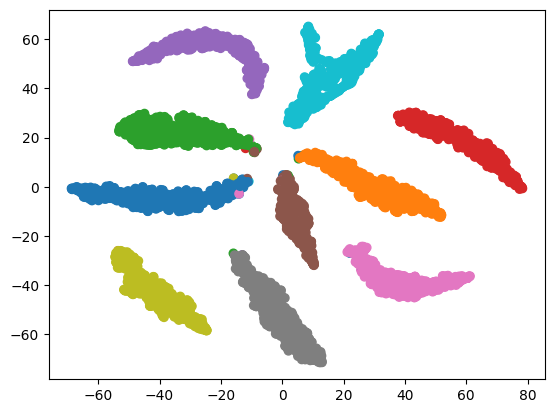

In [98]:
visualize_tsne(embendings, labels)
    

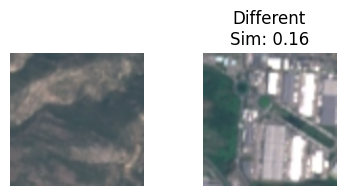

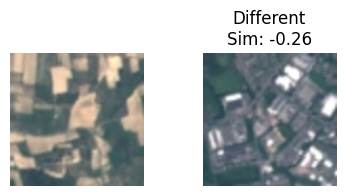

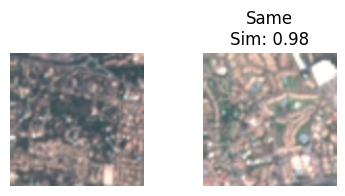

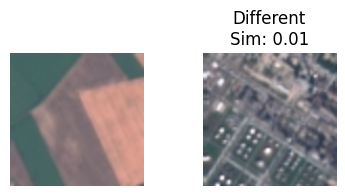

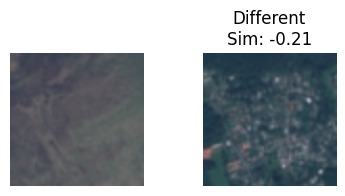

In [115]:
show_image_pairs(model, test_loader.dataset)